# Brain Tumor Detection & Classification
## Pipeline: YOLOv8 (Detection) + Custom CNN (Classification)

**Classes:** Glioma | Meningioma | No Tumor | Pituitary

**Dataset structure expected:**
```
data/
  Train/
    Glioma/images/ + labels/
    Meningioma/images/ + labels/
    No Tumor/images/ + labels/
    Pituitary/images/ + labels/
  Val/
    Glioma/
    Meningioma/
    No Tumor/
    Pituitary/
```

## CELL 1 — Install Dependencies

In [1]:
!pip install ultralytics -q
!pip install kaggle -q

import os, shutil, yaml, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
PyTorch version: 2.10.0+cu128


## CELL 2 — Mount Google Drive & Set Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')


DATASET_ROOT = '/content/drive/MyDrive/archive'

TRAIN_DIR = os.path.join(DATASET_ROOT, 'Train')
VAL_DIR   = os.path.join(DATASET_ROOT, 'Val')

CLASSES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
CLASS2ID = {c: i for i, c in enumerate(CLASSES)}

print(' Dataset root:', DATASET_ROOT)
print('Classes:', CLASSES)

Mounted at /content/drive
 Dataset root: /content/drive/MyDrive/archive
Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


## CELL 3 — Explore & Visualize Dataset

Train samples: {'Glioma': 1153, 'Meningioma': 1449, 'No Tumor': 711, 'Pituitary': 1424}
Val samples:   {'Glioma': 136, 'Meningioma': 140, 'No Tumor': 100, 'Pituitary': 136}


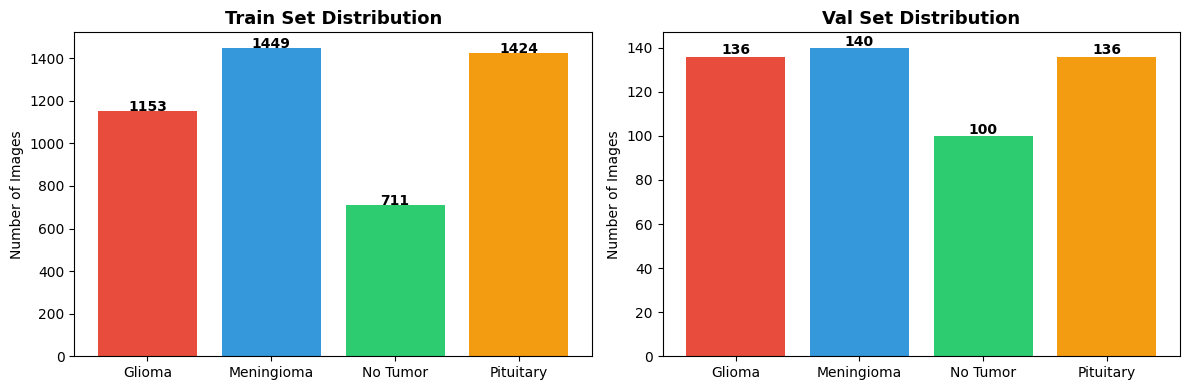

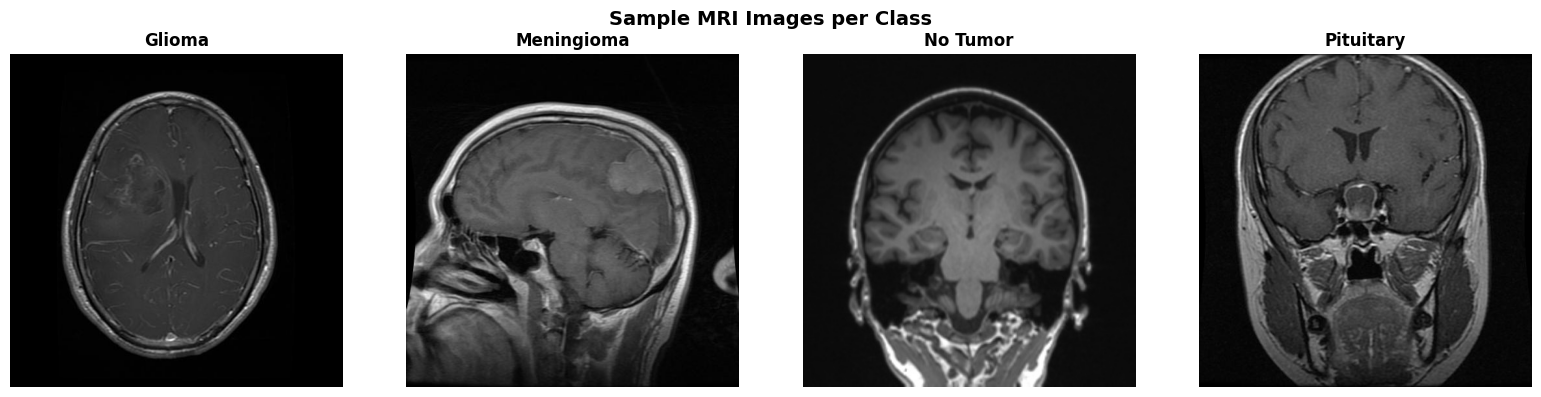

In [3]:
def count_samples(root_dir):
    counts = {}
    for cls in CLASSES:
        img_dir = os.path.join(root_dir, cls, 'images')
        if os.path.exists(img_dir):
            counts[cls] = len(os.listdir(img_dir))
        else:
            counts[cls] = 0
    return counts

train_counts = count_samples(TRAIN_DIR)
val_counts   = count_samples(VAL_DIR)

print('Train samples:', train_counts)
print('Val samples:  ', val_counts)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts)]):
    ax.bar(counts.keys(), counts.values(), color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
    ax.set_title(f'{title} Set Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    for i, v in enumerate(counts.values()):
        ax.text(i, v+1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150)
plt.show()

# Show sample images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    img_dir = os.path.join(TRAIN_DIR, cls, 'images')
    imgs = os.listdir(img_dir)
    if imgs:
        img = Image.open(os.path.join(img_dir, imgs[0])).convert('RGB')
        ax.imshow(img)
        ax.set_title(cls, fontsize=12, fontweight='bold')
        ax.axis('off')
plt.suptitle('Sample MRI Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

---
# PART 1 — YOLOv8 Detection
---

## CELL 4 — Prepare YOLO Dataset Structure

In [5]:
# YOLO expects: images/train, images/val, labels/train, labels/val
YOLO_DIR = '/content/yolo_dataset'

for split in ['train', 'val']:
    os.makedirs(f'{YOLO_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/labels/{split}', exist_ok=True)

def prepare_yolo_split(source_root, split_name):
    """Copy images and labels from class-based structure to YOLO flat structure."""
    count = 0
    for cls in CLASSES:
        cls_id = CLASS2ID[cls]
        img_src = os.path.join(source_root, cls, 'images')
        lbl_src = os.path.join(source_root, cls, 'labels')

        if not os.path.exists(img_src):
            print(f'Missing: {img_src}')
            continue

        for img_file in os.listdir(img_src):
            if not img_file.lower().endswith(('.jpg','.jpeg','.png')):
                continue

            stem = Path(img_file).stem
            src_img = os.path.join(img_src, img_file)
            dst_img = f'{YOLO_DIR}/images/{split_name}/{cls}_{img_file}'
            shutil.copy2(src_img, dst_img)

            # Handle labels
            lbl_file = stem + '.txt'
            src_lbl = os.path.join(lbl_src, lbl_file) if lbl_src else None
            dst_lbl = f'{YOLO_DIR}/labels/{split_name}/{cls}_{stem}.txt'

            if src_lbl and os.path.exists(src_lbl):
                # Rewrite label with correct class id
                with open(src_lbl, 'r') as f:
                    lines = f.readlines()
                with open(dst_lbl, 'w') as f:
                    for line in lines:
                        parts = line.strip().split()
                        if parts:
                            parts[0] = str(cls_id)  # ensure correct class id
                            f.write(' '.join(parts) + '\n')
            else:
                # No label file: create one covering full image (whole-image box)
                with open(dst_lbl, 'w') as f:
                    f.write(f'{cls_id} 0.5 0.5 1.0 1.0\n')
            count += 1

    print(f' {split_name}: {count} samples prepared')

prepare_yolo_split(TRAIN_DIR, 'train')
prepare_yolo_split(VAL_DIR, 'val')

# Create YAML config
yolo_yaml = {
    'path': YOLO_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(CLASSES),
    'names': CLASSES
}

yaml_path = '/content/brain_tumor.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yolo_yaml, f, default_flow_style=False)

print(f' YOLO YAML saved to {yaml_path}')
print(open(yaml_path).read())

 train: 4737 samples prepared
 val: 512 samples prepared
 YOLO YAML saved to /content/brain_tumor.yaml
names:
- Glioma
- Meningioma
- No Tumor
- Pituitary
nc: 4
path: /content/yolo_dataset
train: images/train
val: images/val



## CELL 5 — Train YOLOv8

In [6]:
# Load pretrained YOLOv8 nano (light & fast for Colab)
yolo_model = YOLO('yolov8n.pt')

results = yolo_model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0 if DEVICE == 'cuda' else 'cpu',
    project='/content/yolo_runs',
    name='brain_tumor',
    patience=10,          # early stopping
    lr0=0.01,
    augment=True,
    verbose=True
)

print('\n YOLO Training complete!')
print('Best model saved at:', results.save_dir)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain_tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pe

## CELL 6 — Evaluate YOLO & Plot Metrics

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 845.4±299.4 MB/s, size: 21.0 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 512 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 512/512 165.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 5.6it/s 5.7s
                   all        512        556      0.962      0.925      0.964      0.778
                Glioma        135        165      0.933      0.824      0.917      0.729
            Meningioma        140        148      0.973      0.956       0.99      0.825
              No Tumor        100        100          1      0.998      0.995      0.791
             Pituitary        136        143      0.943      0.922      0.954      0.769
Speed: 2.1ms preprocess, 4.1ms inference, 0.0m

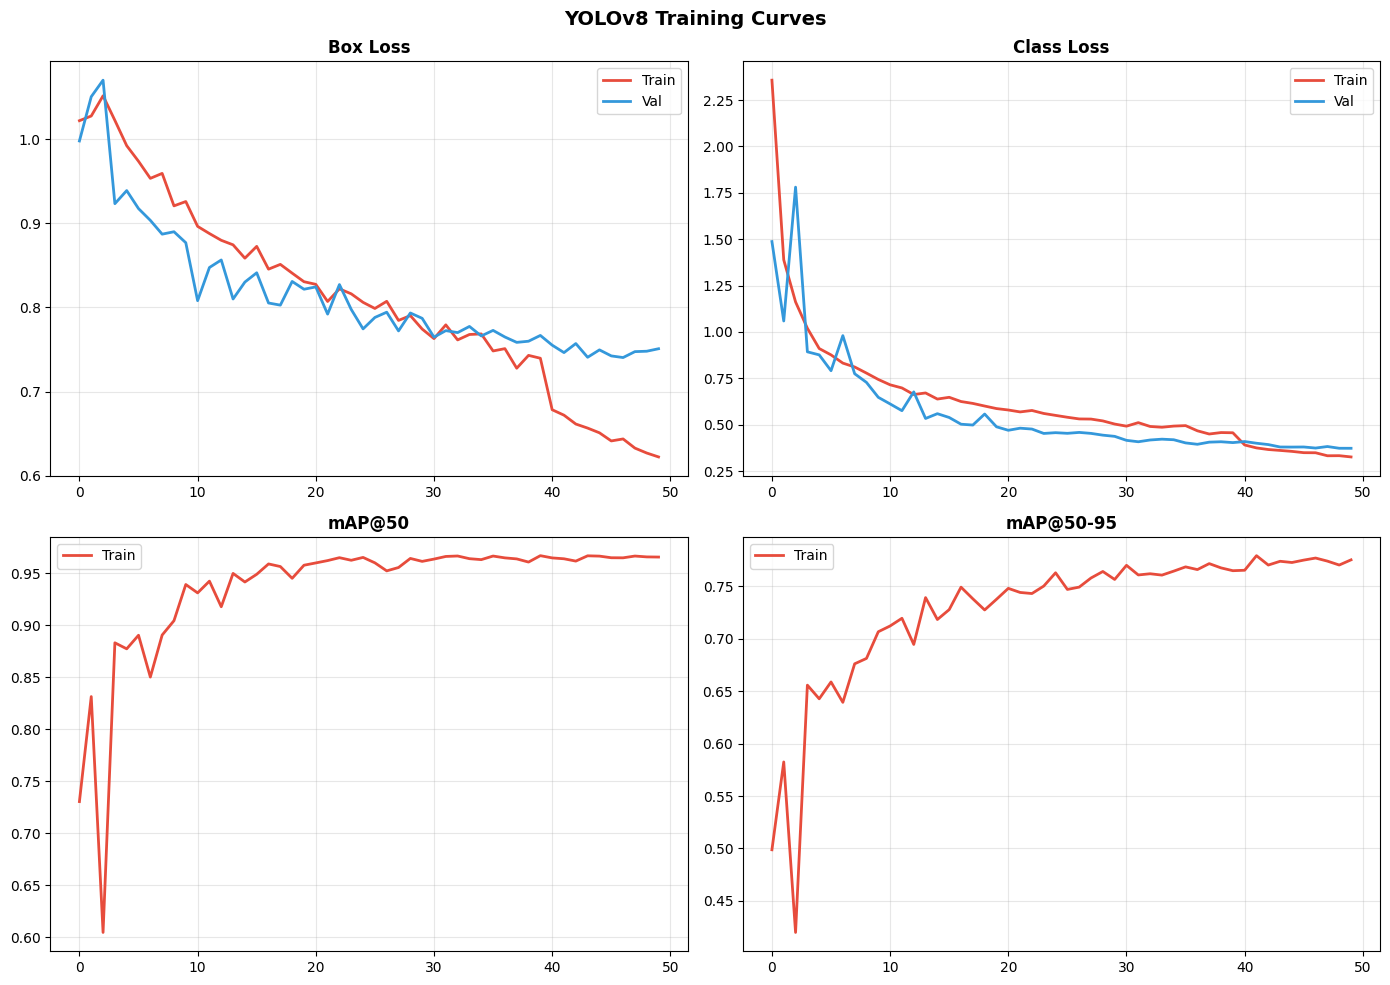

In [7]:
# Load best weights
YOLO_BEST = '/content/yolo_runs/brain_tumor/weights/best.pt'
yolo_trained = YOLO(YOLO_BEST)

# Validate
val_results = yolo_trained.val(data=yaml_path)

print('\n YOLO Validation Metrics:')
print(f'  mAP50:    {val_results.box.map50:.4f}')
print(f'  mAP50-95: {val_results.box.map:.4f}')
print(f'  Precision:{val_results.box.mp:.4f}')
print(f'  Recall:   {val_results.box.mr:.4f}')

# Plot training curves from results.csv
import pandas as pd
results_csv = '/content/yolo_runs/brain_tumor/results.csv'
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Class Loss'),
        ('metrics/mAP50(B)', None, 'mAP@50'),
        ('metrics/mAP50-95(B)', None, 'mAP@50-95'),
    ]
    for ax, (train_col, val_col, title) in zip(axes.flat, metrics):
        if train_col in df.columns:
            ax.plot(df[train_col], label='Train', color='#e74c3c', linewidth=2)
        if val_col and val_col in df.columns:
            ax.plot(df[val_col], label='Val', color='#3498db', linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle('YOLOv8 Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('yolo_training_curves.png', dpi=150)
    plt.show()

---
# PART 2 — CNN Classification
---

## CELL 7 — Prepare CNN Dataset (ImageFolder format)

In [8]:
CNN_DIR = '/content/cnn_dataset'

for split in ['train', 'val']:
    for cls in CLASSES:
        os.makedirs(f'{CNN_DIR}/{split}/{cls}', exist_ok=True)

def prepare_cnn_split(source_root, split_name):
    count = 0
    for cls in CLASSES:
        img_src = os.path.join(source_root, cls, 'images')
        if not os.path.exists(img_src):
            continue
        for img_file in os.listdir(img_src):
            if img_file.lower().endswith(('.jpg','.jpeg','.png')):
                shutil.copy2(
                    os.path.join(img_src, img_file),
                    f'{CNN_DIR}/{split_name}/{cls}/{img_file}'
                )
                count += 1
    print(f'CNN {split_name}: {count} images')

prepare_cnn_split(TRAIN_DIR, 'train')
prepare_cnn_split(VAL_DIR, 'val')

CNN train: 4737 images
CNN val: 512 images


## CELL 8 — Data Loaders & Augmentation

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(f'{CNN_DIR}/train', transform=train_transforms)
val_dataset   = ImageFolder(f'{CNN_DIR}/val',   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2,
                          drop_last=True)
print(f' Train: {len(train_dataset)} images | Val: {len(val_dataset)} images')
print(f'   Class mapping: {train_dataset.class_to_idx}')


 Train: 4737 images | Val: 512 images
   Class mapping: {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}


## CELL 9 — Build CNN Model (EfficientNet-B0 Transfer Learning)

In [13]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()
        # EfficientNet-B0 pretrained backbone
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')

        # Freeze early layers
        for name, param in self.backbone.named_parameters():
            if 'features.0' in name or 'features.1' in name:
                param.requires_grad = False

        # Replace classifier head
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

cnn_model = BrainTumorCNN(num_classes=len(CLASSES)).to(DEVICE)

# Count params
total   = sum(p.numel() for p in cnn_model.parameters())
trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Model: EfficientNet-B0')
print(f'   Total params:     {total:,}')
print(f'   Trainable params: {trainable:,}')
print(cnn_model.backbone.classifier)

Model: EfficientNet-B0
   Total params:     4,666,496
   Trainable params: 4,664,120
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU()
  (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=512, out_features=4, bias=True)
)


## CELL 10 — Training Loop

In [16]:
# Compute class weights to handle imbalance
from collections import Counter
label_counts = Counter(train_dataset.targets)
total_samples = len(train_dataset.targets)
weights = [total_samples / (len(CLASSES) * label_counts[i]) for i in range(len(CLASSES))]
class_weights = torch.FloatTensor(weights).to(DEVICE)
print(' Class weights:', {CLASSES[i]: f'{w:.3f}' for i, w in enumerate(weights)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, cnn_model.parameters()),
                        lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

NUM_EPOCHS = 30
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    # --- TRAIN ---
    cnn_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- VAL ---
    cnn_model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = cnn_model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss = running_loss / total
    val_acc  = correct / total

    scheduler.step()
    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), '/content/best_cnn.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} '
              f'{"⭐" if val_acc == best_val_acc else ""}')

print(f'\n Training complete! Best Val Acc: {best_val_acc:.4f}')

 Class weights: {'Glioma': '1.027', 'Meningioma': '0.817', 'No Tumor': '1.666', 'Pituitary': '0.832'}
Epoch [01/30] Train Loss: 0.0427 Acc: 0.9886 | Val Loss: 0.0256 Acc: 0.9922 ⭐
Epoch [05/30] Train Loss: 0.0180 Acc: 0.9951 | Val Loss: 0.0170 Acc: 0.9980 ⭐
Epoch [10/30] Train Loss: 0.0264 Acc: 0.9922 | Val Loss: 0.0249 Acc: 0.9922 
Epoch [15/30] Train Loss: 0.0108 Acc: 0.9951 | Val Loss: 0.0174 Acc: 0.9961 
Epoch [20/30] Train Loss: 0.0094 Acc: 0.9981 | Val Loss: 0.0085 Acc: 0.9980 ⭐
Epoch [25/30] Train Loss: 0.0009 Acc: 0.9996 | Val Loss: 0.0110 Acc: 0.9961 
Epoch [30/30] Train Loss: 0.0021 Acc: 0.9996 | Val Loss: 0.0179 Acc: 0.9941 

 Training complete! Best Val Acc: 0.9980


## CELL 11 — Plot CNN Training Curves

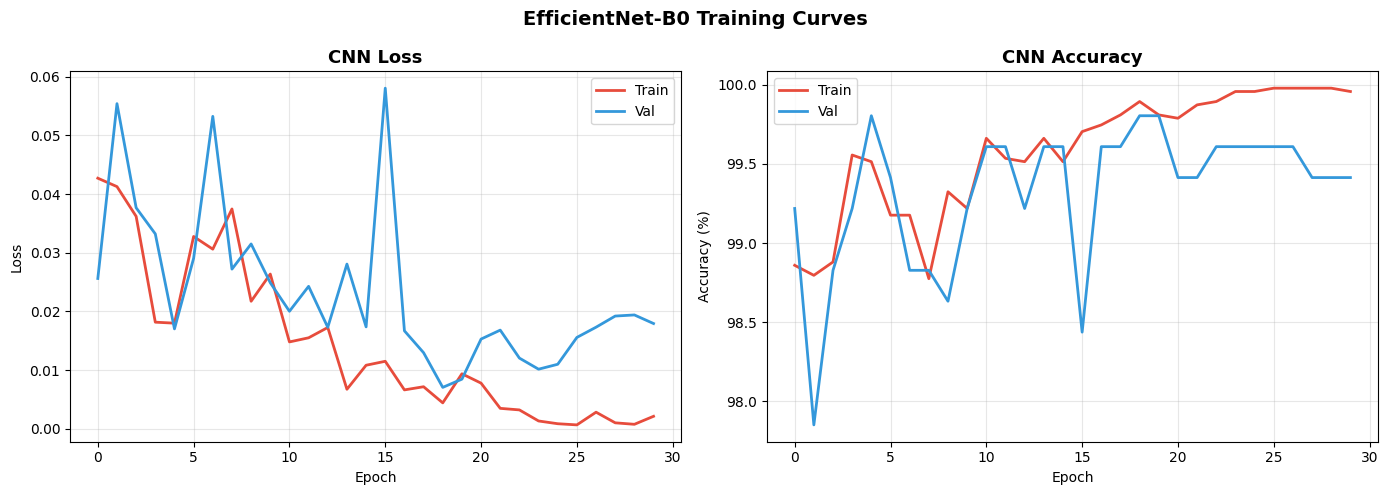

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', color='#e74c3c', linewidth=2)
axes[0].plot(val_losses,   label='Val',   color='#3498db', linewidth=2)
axes[0].set_title('CNN Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in train_accs], label='Train', color='#e74c3c', linewidth=2)
axes[1].plot([a*100 for a in val_accs],   label='Val',   color='#3498db', linewidth=2)
axes[1].set_title('CNN Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

## CELL 12 — Confusion Matrix & Classification Report

Classification Report:
              precision    recall  f1-score   support

      Glioma       0.99      1.00      1.00       136
  Meningioma       1.00      1.00      1.00       140
    No Tumor       1.00      0.99      0.99       100
   Pituitary       1.00      1.00      1.00       136

    accuracy                           1.00       512
   macro avg       1.00      1.00      1.00       512
weighted avg       1.00      1.00      1.00       512



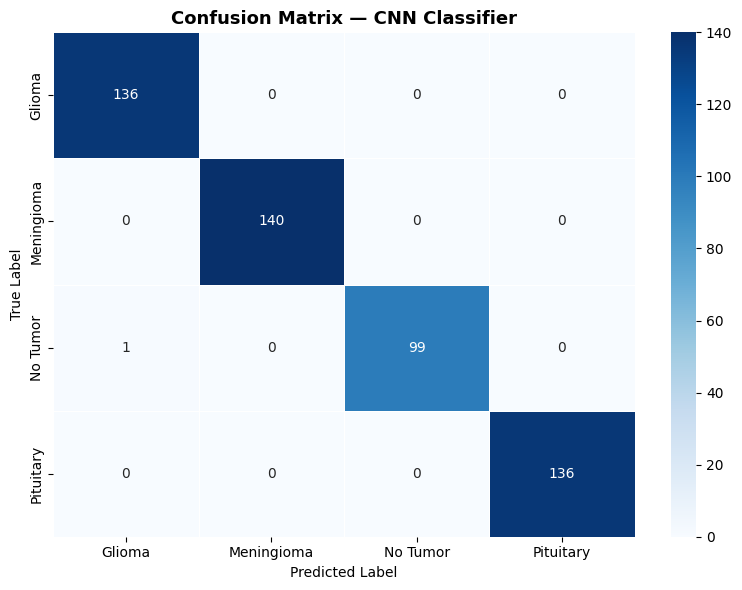

In [18]:
# Load best model
cnn_model.load_state_dict(torch.load('/content/best_cnn.pth'))
cnn_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5)
plt.title('Confusion Matrix — CNN Classifier', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

---
#  PART 3 — Full Pipeline (YOLO + CNN)
---

## CELL 13 — Inference Pipeline

In [ ]:
def predict_pipeline(image_path, yolo_model, cnn_model, conf_threshold=0.3):
    """
    Full pipeline:
    1. YOLO detects tumor region(s)
    2. CNN classifies each detected crop
    Returns annotated image + predictions
    """
    img_pil = Image.open(image_path).convert('RGB')
    img_np  = np.array(img_pil)

    # --- STEP 1: YOLO Detection ---
    yolo_results = yolo_model(image_path, conf=conf_threshold, verbose=False)[0]
    boxes = yolo_results.boxes

    predictions = []

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_np)

    if len(boxes) == 0:
        print(' YOLO: No tumor detected.')
        ax.set_title('No tumor detected by YOLO', color='green', fontsize=14)
    else:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            yolo_conf = float(box.conf[0])
            yolo_cls  = int(box.cls[0])

            # --- STEP 2: CNN Classification on crop ---
            crop = img_pil.crop((x1, y1, x2, y2))
            tensor = val_transforms(crop).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = cnn_model(tensor)
                probs  = torch.softmax(logits, dim=1)[0]
                cnn_cls = torch.argmax(probs).item()
                cnn_conf = float(probs[cnn_cls])

            label = CLASSES[cnn_cls]
            predictions.append({'box': (x1,y1,x2,y2), 'class': label,
                                 'yolo_conf': yolo_conf, 'cnn_conf': cnn_conf})

            # Draw box
            colors = {'Glioma':'#e74c3c','Meningioma':'#3498db',
                      'No Tumor':'#2ecc71','Pituitary':'#f39c12'}
            color = colors.get(label, 'white')
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=3, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-8,
                    f'{label} ({cnn_conf:.0%})',
                    color='white', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))

    ax.axis('off')
    plt.tight_layout()
    plt.savefig('pipeline_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    return predictions

print(' Pipeline function ready!')

 Pipeline function ready!


## CELL 14 — Test on Sample Images

Testing on 4 sample images...

--- Image: gg (487).jpg ---


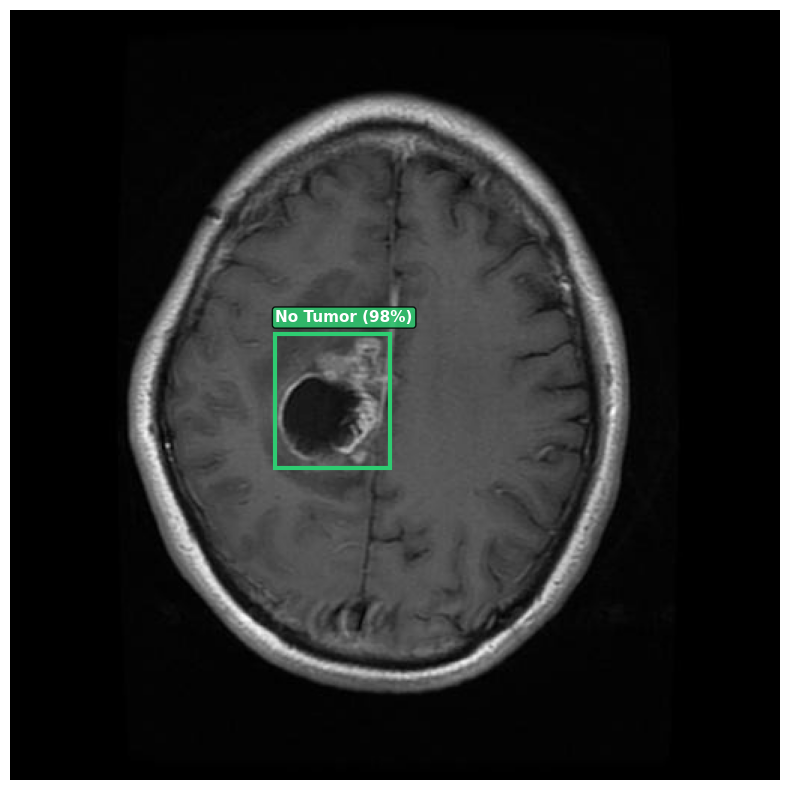

   Detected: No Tumor | YOLO conf: 0.86 | CNN conf: 0.98

--- Image: m1(187).jpg ---


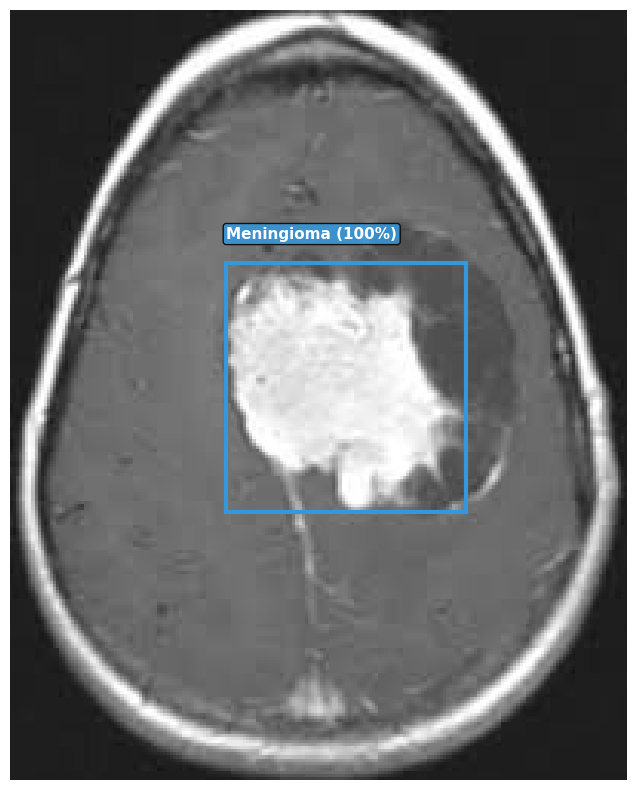

   Detected: Meningioma | YOLO conf: 0.93 | CNN conf: 1.00

--- Image: image(45).jpg ---


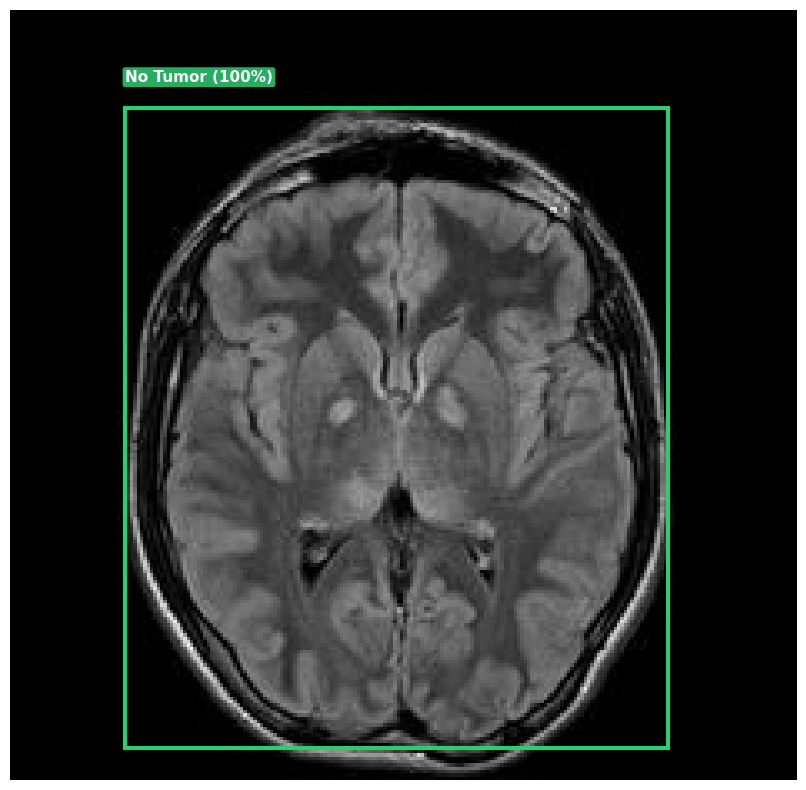

   Detected: No Tumor | YOLO conf: 0.89 | CNN conf: 1.00

--- Image: Tr-pi_0194.jpg ---


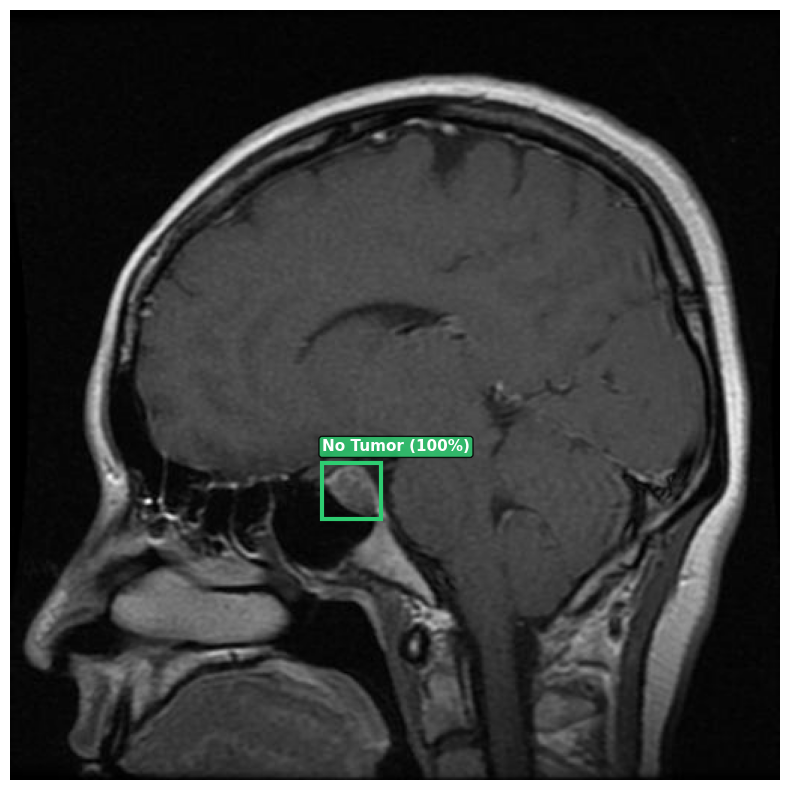

   Detected: No Tumor | YOLO conf: 0.86 | CNN conf: 1.00



In [20]:
# Load models
yolo_trained = YOLO(YOLO_BEST)
cnn_model.load_state_dict(torch.load('/content/best_cnn.pth'))
cnn_model.eval()

# Test on a few validation images
test_images = []
for cls in CLASSES:
    img_dir = os.path.join(VAL_DIR, cls, 'images')
    if os.path.exists(img_dir):
        imgs = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs:
            test_images.append(random.choice(imgs))

print(f'Testing on {len(test_images)} sample images...\n')
for img_path in test_images:
    print(f'--- Image: {os.path.basename(img_path)} ---')
    preds = predict_pipeline(img_path, yolo_trained, cnn_model)
    for p in preds:
        print(f'   Detected: {p["class"]} | YOLO conf: {p["yolo_conf"]:.2f} | CNN conf: {p["cnn_conf"]:.2f}')
    print()

## CELL 15 — Save Models to Drive

In [21]:
SAVE_DIR = '/content/drive/MyDrive/brain_tumor_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save YOLO best weights
shutil.copy2(YOLO_BEST, f'{SAVE_DIR}/yolo_best.pt')

# Save CNN weights
torch.save(cnn_model.state_dict(), f'{SAVE_DIR}/cnn_best.pth')

# Save plots
for plot in ['dataset_distribution.png','yolo_training_curves.png',
             'cnn_training_curves.png','confusion_matrix.png','pipeline_result.png']:
    if os.path.exists(f'/content/{plot}'):
        shutil.copy2(f'/content/{plot}', f'{SAVE_DIR}/{plot}')

print(f'All models and plots saved to {SAVE_DIR}')
print(' Files saved:')
for f in os.listdir(SAVE_DIR):
    print(f'   - {f}')

All models and plots saved to /content/drive/MyDrive/brain_tumor_models
 Files saved:
   - yolo_best.pt
   - cnn_best.pth
   - dataset_distribution.png
   - yolo_training_curves.png
   - cnn_training_curves.png
   - confusion_matrix.png
   - pipeline_result.png


---
##  Summary

| Component | Details |
|-----------|--------|
| **Detection** | YOLOv8n — fine-tuned on MRI images |
| **Classification** | EfficientNet-B0 — Transfer Learning |
| **Classes** | Glioma, Meningioma, No Tumor, Pituitary |
| **Augmentation** | Flip, Rotation, ColorJitter, Affine |
| **Loss** | CrossEntropy with class weights |
| **Optimizer** | AdamW + CosineAnnealing LR |

### Pipeline Flow:
```
MRI Image → YOLOv8 (detect & crop tumor) → EfficientNet-B0 (classify type) → Result
```